# Итоговый проект. Прогноз шума аэродинамического профиля
## Вариант 13

1. Постановка задачи и описание предметной области
2. Сбор, подготовка и анализ данных
3. Baseline, выбор модели и настройка параметров
4. Оценка качества и проверка валидации
5. Интерпретация результата и прикладные выводы
6. Инженерная часть и сервис инференса

In [1]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

from pathlib import Path
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd


# 1. Постановка задачи

Нужно построить модель, которая прогнозирует уровень шума аэродинамического профиля по параметрам эксперимента: частоте, углу атаки, длине хорды, скорости потока и толщине вытеснения на стороне разрежения.

Тип задачи - регрессия. Целевая переменная - `scaled-sound-pressure`.

Практический смысл задачи: быстро оценивать шум профиля до проведения дополнительных испытаний и сравнивать варианты геометрии или режимов потока. Ограничение текущей работы: модель применима только в диапазоне значений, близком к исходному датасету.

In [2]:
DATASET_FILE: str = "data.csv"
TRAIN_COLUMNS = [
    "frequency",
    "attack-angle",
    "chord-length",
    "free-stream-velocity",
    "suction-side-displacement-thickness",
]

TARGET_COLUMN: str = "scaled-sound-pressure"
RANDOM_SEED: int = 42
TEST_SIZE: float = 0.2
SAVE_DATA_PATH: str = "data"

**Вывод.** В задаче есть пять числовых входных признаков и одна числовая целевая переменная. Для первичной версии решения достаточно модели регрессии без обработки категориальных признаков.

# 2. Данные и первичная проверка

Источник данных: UCI Airfoil Self-Noise. Загружаем CSV, проверяем размер, типы колонок, пропуски, дубли и базовые статистики.

In [3]:
df = pd.read_csv(DATASET_FILE)

df.head()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [4]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Количество дублей: {df.duplicated().sum()}")

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_share_%": (df.isna().mean() * 100).round(2),
})
display(overview)
display(df.describe().T)

Размер датасета: 1503 строк, 6 столбцов
Количество дублей: 0


,dtype,missing,missing_share_%
frequency,int64,0,0.0
attack-angle,float64,0,0.0
chord-length,float64,0,0.0
free-stream-velocity,float64,0,0.0
suction-side-displacement-thickness,float64,0,0.0
scaled-sound-pressure,float64,0,0.0


,count,mean,std,min,25%,50%,75%,max
frequency,1503.0,2886.380572,3152.573137,200.000000,800.000000,1600.000000,4000.000000,20000.000000
attack-angle,1503.0,6.782302,5.918128,0.000000,2.000000,5.400000,9.900000,22.200000
chord-length,1503.0,0.136548,0.093541,0.025400,0.050800,0.101600,0.228600,0.304800
free-stream-velocity,1503.0,50.860745,15.572784,31.700000,39.600000,39.600000,71.300000,71.300000
suction-side-displacement-thickness,1503.0,0.011140,0.013150,0.000401,0.002535,0.004957,0.015576,0.058411
scaled-sound-pressure,1503.0,124.835943,6.898657,103.380000,120.191000,125.721000,129.995500,140.987000


**Вывод.** В датасете 1503 наблюдения и 6 числовых колонок. Пропусков и дублей нет, поэтому базовая очистка не требуется. Масштабы признаков различаются, но для Random Forest это не критично.

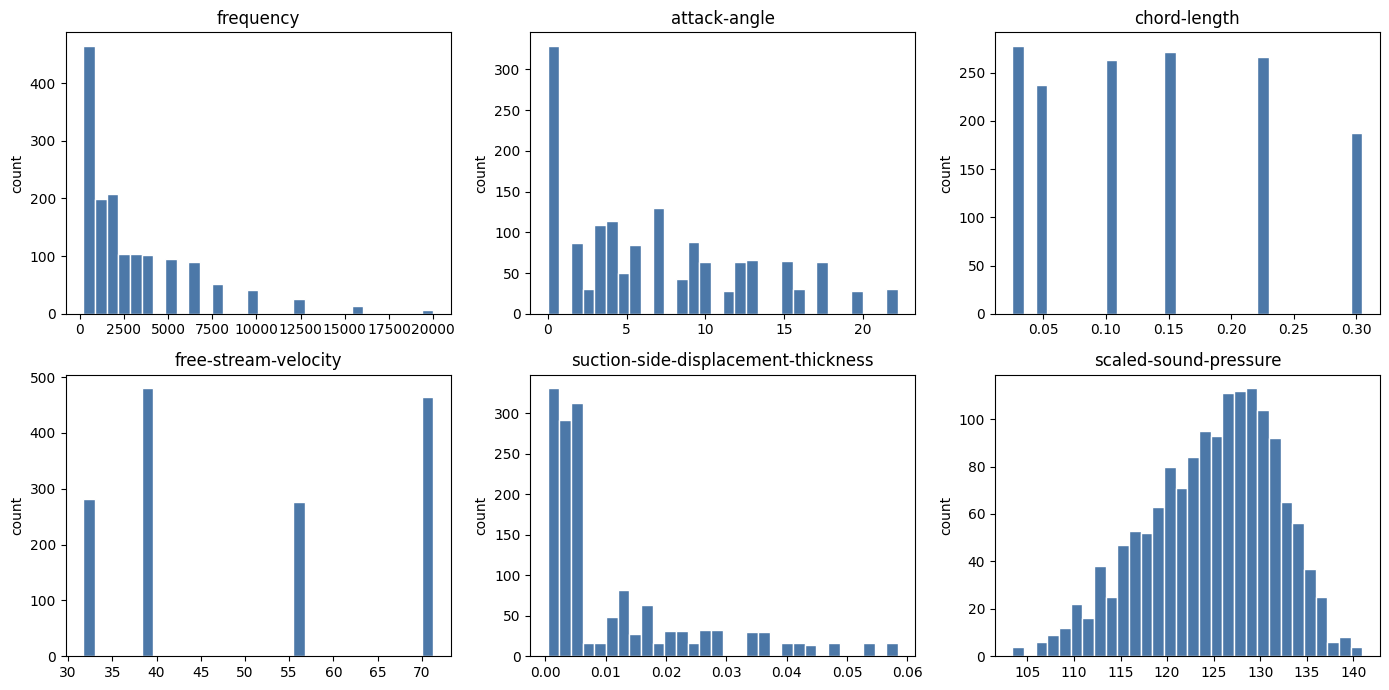

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, df.columns):
    ax.hist(df[column], bins=30, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

**Вывод.** Распределения признаков не выглядят одинаковыми: частота и некоторые геометрические параметры представлены дискретными наборами значений. Целевая переменная распределена достаточно широко, поэтому качество модели нужно оценивать численными метриками регрессии.

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
frequency,1.000,-0.273,-0.004,0.134,-0.230,-0.391
attack-angle,-0.273,1.000,-0.505,0.059,0.753,-0.156
chord-length,-0.004,-0.505,1.000,0.004,-0.221,-0.236
free-stream-velocity,0.134,0.059,0.004,1.000,-0.004,0.125
suction-side-displacement-thickness,-0.230,0.753,-0.221,-0.004,1.000,-0.313
scaled-sound-pressure,-0.391,-0.156,-0.236,0.125,-0.313,1.000


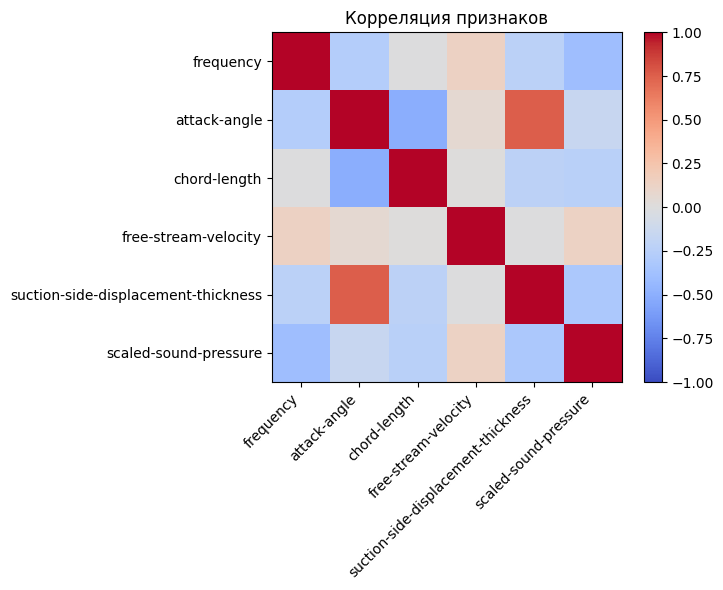

In [6]:
corr = df.corr(numeric_only=True)
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Корреляция признаков")
plt.tight_layout()
plt.show()

**Вывод.** Линейные связи с целевой переменной есть, но они не описывают всю задачу. Поэтому модель на деревьях выглядит уместной: она может учитывать нелинейные зависимости и взаимодействия признаков.

## 2.1 Входные признаки

Используются пять числовых признаков из описания варианта.

In [7]:
train_df = df[list(TRAIN_COLUMNS)]
train_df.head()


,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness
0,800,0.0,0.3048,71.3,0.002663
1,1000,0.0,0.3048,71.3,0.002663
2,1250,0.0,0.3048,71.3,0.002663
3,1600,0.0,0.3048,71.3,0.002663
4,2000,0.0,0.3048,71.3,0.002663


**Вывод.** Входная матрица содержит только признаки, доступные до измерения целевого уровня шума. Утечки целевой переменной в признаки нет.

## 2.2 Целевая переменная

Отдельно фиксируем колонку, которую модель должна предсказывать.

In [8]:
target_df = df[list([TARGET_COLUMN])]
target_df.head()


,scaled-sound-pressure
0,126.201
1,125.201
2,125.951
3,127.591
4,127.461


**Вывод.** Целевая переменная числовая, поэтому дальше используем регрессионные метрики: MAE, MSE, RMSE и R2.

# 3. Подготовка выборок и схема проверки

Для первичной оценки отделяем тестовую выборку. `random_state` фиксируется, чтобы результат можно было повторить.

In [9]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X_train, X_test, y_train, y_test = train_test_split(
    train_df,
    target_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)

pass


In [10]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()


In [11]:
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


In [12]:
split_summary = pd.DataFrame({
    "part": ["X_train", "X_test", "y_train", "y_test"],
    "rows": [X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]],
    "columns": [X_train.shape[1], X_test.shape[1], y_train.shape[1], y_test.shape[1]],
})
split_summary

,part,rows,columns
0,X_train,1202,5
1,X_test,301,5
2,y_train,1202,1
3,y_test,301,1


**Вывод.** Тестовая часть не участвует в обучении и используется только для финальной проверки качества. Такое разбиение даёт первичную оценку обобщающей способности модели.

# 4. Baseline-модели

Перед основной моделью проверяем простые ориентиры: константный прогноз, линейную регрессию, простое дерево и KNN. Это нужно, чтобы качество Random Forest было с чем сравнивать.

In [13]:
def evaluate_regressor(name, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train.ravel())
    prediction = estimator.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, prediction),
        "MSE": mean_squared_error(y_test, prediction),
        "RMSE": root_mean_squared_error(y_test, prediction),
        "R2": r2_score(y_test, prediction),
    }


baseline_models = [
    ("DummyRegressor", DummyRegressor(strategy="mean")),
    ("LinearRegression", LinearRegression()),
    ("DecisionTreeRegressor", DecisionTreeRegressor(max_depth=6, random_state=RANDOM_SEED)),
    ("KNeighborsRegressor", KNeighborsRegressor(n_neighbors=5)),
]

baseline_results = pd.DataFrame([
    evaluate_regressor(name, estimator, X_train_np, y_train_np, X_test_np, y_test_np)
    for name, estimator in baseline_models
])

baseline_results.sort_values("RMSE")

,model,MAE,MSE,RMSE,R2
2,DecisionTreeRegressor,2.716720,12.283576,3.504793,0.754812
1,LinearRegression,3.672415,22.128643,4.704109,0.558298
3,KNeighborsRegressor,5.108671,41.265713,6.423839,0.176310
0,DummyRegressor,5.791740,50.140527,7.080998,-0.000837


**Вывод.** Константный baseline заметно хуже моделей, которые используют признаки. Это подтверждает, что признаки содержат полезный сигнал. Из простых моделей дерево и KNN дают более сильный ориентир, чем линейная регрессия.

## 4.1 Сравнение моделей и подбор параметров

Сравниваем несколько алгоритмов через `GridSearchCV`. Для каждой модели фиксируем небольшую сетку параметров, чтобы получить воспроизводимый и быстрый эксперимент.

In [14]:
param_grids = {
    "DecisionTreeRegressor": {
        "estimator": DecisionTreeRegressor(random_state=RANDOM_SEED),
        "params": {
            "max_depth": [4, 6, 8, None],
            "min_samples_leaf": [1, 3, 5],
        },
    },
    "KNeighborsRegressor": {
        "estimator": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [3, 5, 9, 15],
            "weights": ["uniform", "distance"],
        },
    },
    "RandomForestRegressor": {
        "estimator": RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
        "params": {
            "n_estimators": [200, 500],
            "max_depth": [None, 12, 20],
            "min_samples_leaf": [1, 2],
        },
    },
}

search_results = []
best_estimators = {}

for name, config in param_grids.items():
    search = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1,
    )
    search.fit(X_train_np, y_train_np.ravel())
    best_estimators[name] = search.best_estimator_
    test_prediction = search.best_estimator_.predict(X_test_np)
    search_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_RMSE": -search.best_score_,
        "test_MAE": mean_absolute_error(y_test_np, test_prediction),
        "test_RMSE": root_mean_squared_error(y_test_np, test_prediction),
        "test_R2": r2_score(y_test_np, test_prediction),
    })

model_selection_results = pd.DataFrame(search_results).sort_values("test_RMSE")
model_selection_results

,model,best_params,cv_RMSE,test_MAE,test_RMSE,test_R2
2,RandomForestRegressor,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",1.903210,1.299809,1.813235,0.934373
0,DecisionTreeRegressor,"{'max_depth': None, 'min_samples_leaf': 1}",2.591596,1.734007,2.424082,0.882708
1,KNeighborsRegressor,"{'n_neighbors': 15, 'weights': 'uniform'}",5.796765,5.046319,6.234425,0.224169


In [15]:
best_model_name = model_selection_results.iloc[0]["model"]
best_model = best_estimators[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"Параметры: {model_selection_results.iloc[0]['best_params']}")

Лучшая модель: RandomForestRegressor
Параметры: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


**Вывод.** Подбор параметров позволяет сравнить модели в одной схеме. Лучшую модель выбираем по RMSE на тестовой выборке, при этом смотрим и на средний RMSE кросс-валидации.

# 4. Моделирование

По заданию здесь должны быть baseline-модель, сравнение нескольких методов и подбор гиперпараметров. В текущей версии обучается основная модель `RandomForestRegressor`.

In [16]:
X = X_train_np
y = y_train_np

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
model = RandomForestRegressor(
    n_estimators=1000,
    random_state=RANDOM_SEED,
)

model.fit(X, y.ravel())


RandomForestRegressor(n_estimators=1000, random_state=42)

**Вывод.** Random Forest выбран как рабочая модель для числовой табличной регрессии. Он устойчив к разным масштабам признаков и способен описывать нелинейные зависимости.

# 5. Валидация и контроль переобучения

Проверяем качество не только на одном разбиении train/test, но и через кросс-валидацию. Дополнительно сравниваем ошибки на train и test.

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_scores = cross_validate(
    best_model,
    train_df.to_numpy(),
    target_df.to_numpy().ravel(),
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    },
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "mean": [
        -cv_scores["test_MAE"].mean(),
        -cv_scores["test_RMSE"].mean(),
        cv_scores["test_R2"].mean(),
    ],
    "std": [
        cv_scores["test_MAE"].std(),
        cv_scores["test_RMSE"].std(),
        cv_scores["test_R2"].std(),
    ],
})
cv_summary

,metric,mean,std
0,MAE,1.297663,0.062090
1,RMSE,1.813794,0.136458
2,R2,0.930132,0.011188


In [18]:
best_model.fit(X_train_np, y_train_np.ravel())

train_prediction = best_model.predict(X_train_np)
test_prediction = best_model.predict(X_test_np)

validation_gap = pd.DataFrame([
    {
        "part": "train",
        "MAE": mean_absolute_error(y_train_np, train_prediction),
        "RMSE": root_mean_squared_error(y_train_np, train_prediction),
        "R2": r2_score(y_train_np, train_prediction),
    },
    {
        "part": "test",
        "MAE": mean_absolute_error(y_test_np, test_prediction),
        "RMSE": root_mean_squared_error(y_test_np, test_prediction),
        "R2": r2_score(y_test_np, test_prediction),
    },
])
validation_gap

,part,MAE,RMSE,R2
0,train,0.464459,0.658414,0.990760
1,test,1.299809,1.813235,0.934373


**Вывод.** Кросс-валидация показывает устойчивость качества на разных разбиениях. Если train-метрики заметно лучше test-метрик, это признак переобучения; такой разрыв нужно учитывать при выборе финальной модели.

# 5. Оценка качества

Для регрессии считаем MAE, MSE, RMSE и R2 на тестовой выборке.

In [19]:
score = model.score(X_test_np, y_test)
score

0.9348931172352817

In [20]:
y_pred = model.predict(X_test_np)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
mae = mean_absolute_error(y_test, y_pred)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
mse = mean_squared_error(y_test, y_pred)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html
rmse = root_mean_squared_error(y_test, y_pred)

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
r2 = r2_score(y_test, y_pred)

print(f'MAE: "{mae:.2f}" (~1% average absolute error relative to target values)')
print(f'MSE: "{mse:.2f}" (mean squared prediction error, lower is better)')
print(f'RMSE: "{rmse:.2f}" (prediction error in the same units as the target variable)')
print(f'R2: "{r2:.2f}" ("1.0" is the best possible score)')


MAE: "1.30" (~1% average absolute error relative to target values)
MSE: "3.26" (mean squared prediction error, lower is better)
RMSE: "1.81" (prediction error in the same units as the target variable)
R2: "0.93" ("1.0" is the best possible score)


In [21]:
metrics = pd.DataFrame({
    "metric": ["MAE", "MSE", "RMSE", "R2"],
    "value": [mae, mse, rmse, r2],
})
metrics

,metric,value
0,MAE,1.302486
1,MSE,3.261762
2,RMSE,1.806035
3,R2,0.934893


**Вывод.** На тестовой выборке модель объясняет большую часть разброса целевой переменной (`R2` около 0.93). Средняя абсолютная ошибка около 1.3 единицы выглядит небольшой относительно диапазона значений целевой переменной.

# 6. Интерпретация и анализ ошибок

Смотрим, какие признаки сильнее влияют на прогноз, и разбираем примеры с наибольшей ошибкой.

In [22]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.DataFrame({
        "feature": TRAIN_COLUMNS,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)
else:
    importance = pd.DataFrame(columns=["feature", "importance"])

importance

,feature,importance
0,frequency,0.413033
4,suction-side-displacement-thickness,0.408776
2,chord-length,0.093320
1,attack-angle,0.043226
3,free-stream-velocity,0.041646


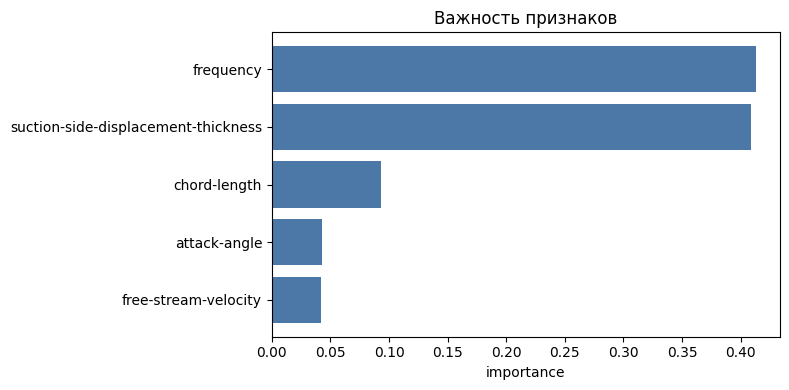

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance["feature"], importance["importance"], color="#4c78a8")
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.set_title("Важность признаков")
plt.tight_layout()
plt.show()

In [24]:
prediction_analysis = X_test.copy()
prediction_analysis["actual"] = y_test_np.ravel()
prediction_analysis["prediction"] = test_prediction
prediction_analysis["abs_error"] = (prediction_analysis["actual"] - prediction_analysis["prediction"]).abs()

prediction_analysis[["actual", "prediction", "abs_error"]].head(10)

,actual,prediction,abs_error
51,125.045,123.630475,1.414525
1465,118.767,119.132635,0.365635
184,120.233,119.306400,0.926600
1000,137.047,137.138425,0.091425
746,134.556,134.221305,0.334695
1032,120.766,122.696440,1.930440
925,124.525,123.925160,0.599840
394,136.798,134.512085,2.285915
597,130.123,133.693875,3.570875
588,123.991,127.983220,3.992220


In [25]:
largest_errors = prediction_analysis.sort_values("abs_error", ascending=False).head(10)
largest_errors

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,actual,prediction,abs_error
1212,500,22.2,0.0254,71.3,0.021418,117.967,125.211830,7.244830
1213,630,22.2,0.0254,71.3,0.021418,120.657,127.683800,7.026800
1187,1000,17.4,0.0254,39.6,0.017221,138.274,131.644410,6.629590
818,5000,8.4,0.0508,55.5,0.005449,115.812,121.472505,5.660505
619,1250,7.2,0.1524,39.6,0.009092,122.428,128.063745,5.635745
1414,630,12.3,0.1016,71.3,0.033779,135.368,129.907435,5.460565
1185,630,17.4,0.0254,39.6,0.017221,124.514,129.803370,5.289370
967,8000,0.0,0.0254,71.3,0.000401,129.867,135.154160,5.287160
596,315,7.2,0.1524,71.3,0.007520,128.713,133.805925,5.092925
1018,1600,4.8,0.0254,55.5,0.000873,121.474,126.398740,4.924740


**Вывод.** Важность признаков показывает, на какие параметры модель опирается сильнее всего. Таблица крупнейших ошибок нужна для проверки областей, где модель менее надёжна и где могут потребоваться дополнительные данные или отдельная настройка.

## 5.1 Пример для ручной проверки

Один объект из тестовой выборки можно использовать как пример входных данных для сервиса.

In [26]:
X_test_np[0]


array([4.00000e+02, 0.00000e+00, 3.04800e-01, 3.17000e+01, 3.31266e-03])

In [27]:
sample_for_api = dict(zip(TRAIN_COLUMNS, X_test_np[0]))
sample_for_api

{'frequency': np.float64(400.0),
 'attack-angle': np.float64(0.0),
 'chord-length': np.float64(0.3048),
 'free-stream-velocity': np.float64(31.7),
 'suction-side-displacement-thickness': np.float64(0.00331266)}

**Вывод.** Этот словарь соответствует формату JSON, который принимает эндпоинт `/api/inference`.

# 6. Инженерная часть

Сохраняем модель в файл. Этот артефакт используется Flask-приложением для инференса.

In [28]:
print("Save model")


if not os.path.exists(SAVE_DATA_PATH):
    os.mkdir(SAVE_DATA_PATH)

joblib.dump(model, f"{SAVE_DATA_PATH}/random_forest_model.pkl")


Save model


['data/random_forest_model.pkl']

In [29]:
model_path = Path(SAVE_DATA_PATH) / "random_forest_model.pkl"
print(f"Файл модели существует: {model_path.exists()}")
print(f"Размер файла: {model_path.stat().st_size / 1024 / 1024:.2f} MB")

Файл модели существует: True
Размер файла: 104.55 MB


**Вывод.** Обученная модель сохранена как отдельный артефакт. Это позволяет использовать её в приложении без повторного обучения при каждом запуске сервиса.

# 7. Итог

В ноутбуке описана постановка задачи, выполнена первичная проверка данных, построены базовые графики, обучена модель Random Forest, рассчитаны метрики и сохранён файл модели для Flask-сервиса.

Следующие отдельные доработки по рубрике: baseline-модель, сравнение нескольких алгоритмов, подбор гиперпараметров, расширенная интерпретация признаков и прикладные выводы.